# Modelo LightGBM Avanzado y Balanceado (Bank Marketing)

El objetivo de este notebook es construir un modelo predictivo robusto para la clase minoritaria (conversión al depósito a término fijo `yes` = 1), manejando el fuerte desbalance del dataset sin recurrir al submuestreo pesado ni sacrificar por completo la precisión.

**Objetivos de la sesión:**
1. Crear un preprocesamiento basado en la ingeniería de características (Feature Engineering).
2. Entrenar y optimizar `LGBMClassifier` focalizado en `f1_score` usando balanceo intrínseco de pesos (`scale_pos_weight`).
3. Refinar las predicciones mediante la optimización geométrica del umbral de decisión (Decision Threshold).
4. Lograr un equilibrio aproximado: **precision ~0.49**, **recall ~0.50**, **f1 ~0.50**.

In [1]:
import sys
import os
import warnings

# Para asegurar que la ruta al root esté cargada en python y src y data funcionen
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, 
    roc_curve, roc_auc_score, auc, f1_score
)

import optuna
from optuna.samplers import TPESampler
from lightgbm import LGBMClassifier

# Modulos customizados del proyecto
from data.loader import load_bank_data
from src.features.build_features import BankFeatureEngineer

sns.set_theme(style="whitegrid")

## 1. Carga de Datos y División (Train / Test)

Calcularemos la proporción de desbalance para indicarle a `LightGBM` cuánto deberá penalizar los errores cometidos en la clase minoritaria.

In [2]:
# Cargar datos desde UCI directamente eliminando 'duration'
X, y = load_bank_data(drop_duration=True)

# Splits estratificados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cálculo del scale_pos_weight = negativos / positivos
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos

print(f"Dimensión Train: {X_train.shape}")
print(f"Dimensión Test:  {X_test.shape}")
print(f"Proporción de clase positiva en Train: {positivos/len(y_train):.2%}")
print(f"Calculado scale_pos_weight: {scale_pos_weight:.2f}")

Descargando el dataset 'Bank Marketing' (ID 222)...
Variable 'duration' omitida correctamente.
Dimensión Train: (36168, 15)
Dimensión Test:  (9043, 15)
Proporción de clase positiva en Train: 11.70%
Calculado scale_pos_weight: 7.55


## 2. Preparación del Pipeline de Sklearn

Diferenciamos las variables por tipo (numéricas, categóricas y booleanas custom) originadas tras pasar por nuestro `BankFeatureEngineer`.

In [3]:
def create_pipeline(estimator=None):
    """
    Construye el pipeline completo de preprocesado + modelo.
    """
    # Identificar variables una vez que salgan del estimador custom
    # Utilizaremos una muestra para capturar los nombres
    fe = BankFeatureEngineer()
    X_sample = fe.fit_transform(X_train.head())
    
    num_vars = X_sample.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_vars = X_sample.select_dtypes(include=['object', 'category']).columns.tolist()
    
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_vars),
            ('cat', cat_transformer, cat_vars)
        ],
        remainder='passthrough'
    )
    
    steps = [
        ('feature_engineer', BankFeatureEngineer()),
        ('preprocessor', preprocessor)
    ]
    
    if estimator is not None:
        steps.append(('classifier', estimator))
        
    return Pipeline(steps)

# Verificamos
try_pipeline = create_pipeline()
try_pipeline.fit(X_train)
print("Pipeline base creado con éxito.")

Pipeline base creado con éxito.


## 3. Optimización de Hiperparámetros (LGBM + Optuna)

Definimos una función objetivo de Optuna enfocada explícitamente en el **F1 de la clase positiva**. Queremos robustez por lo cual empleamos `StratifiedKFold`.

In [4]:
def objective(trial):
    param = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # LightGBM permite modificar su severidad con subsample_freq
        'subsample_freq': 1,
        'scale_pos_weight': scale_pos_weight, 
        'random_state': 42,
        'n_jobs': 1
    }
    
    model = LGBMClassifier(**param)
    pipeline = create_pipeline(estimator=model)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Extraer las probabilidades de las validaciones en oof
    y_preds_cv = cross_val_predict(
        pipeline, X_train, y_train, 
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    # Predecir con el threshold clásico (0.5), aunque luego optimicemos este aspect para validación rápida
    y_pred_bin_cv = (y_preds_cv >= 0.5).astype(int)
    
    # Retornamos el f1 macro o directamente el de la clase minoritaria (pos: 1)
    f1 = f1_score(y_train, y_pred_bin_cv)
    return f1

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler, study_name="LGBM_F1_Optimization")
# Ejecutar optimización. Puedes cambiar n_trials a 50 para resultados reales (reducido para modo interactivo)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Mejor valor F1 en cross-validation:", study.best_value)
print("Mejores parámetros encontrados:\n", study.best_params)

[I 2026-05-20 21:32:44,748] A new study created in memory with name: LGBM_F1_Optimization
  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 779
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116990 -> initscore=-2.021244
[LightGBM] [Info] Start training from score -2.021244
[LightGBM] [Info] Number of positive: 3385, number of negative: 25550
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 28935, number of used features: 48
[LightGBM] [Info] [bin

Best trial: 0. Best value: 0.442311:   3%|▎         | 1/30 [00:06<03:00,  6.21s/it]

[I 2026-05-20 21:32:50,956] Trial 0 finished with value: 0.44231117551168264 and parameters: {'num_leaves': 69, 'max_depth': 20, 'learning_rate': 0.029106359131330698, 'n_estimators': 399, 'min_child_samples': 32, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.44231117551168264.
[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116990 -> initscore=-2.021244
[LightGBM] [Info] Start training from score -2.021244
[LightGBM] [Warning] No further splits

Best trial: 0. Best value: 0.442311:   7%|▋         | 2/30 [00:10<02:24,  5.17s/it]

...

[I 2026-05-20 21:33:45,689] Trial 27 finished with value: 0.42840395243677776 and parameters: {'num_leaves': 39, 'max_depth': 10, 'learning_rate': 0.054226392300199405, 'n_estimators': 104, 'min_child_samples': 50, 'subsample': 0.7213974560013007, 'colsample_bytree': 0.796890640185499, 'reg_alpha': 8.218703343303167, 'reg_lambda': 2.210595670005655e-06}. Best is trial 12 with value: 0.4559009843095215.
[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116990 -> initscore=-2.021244
[LightGBM] [Info] Start training from score -2.021244
[LightGBM] [Info] Number of positive: 

Best trial: 12. Best value: 0.455901:  97%|█████████▋| 29/30 [01:02<00:01,  1.44s/it]

[I 2026-05-20 21:33:47,322] Trial 28 finished with value: 0.44342973110096395 and parameters: {'num_leaves': 53, 'max_depth': 13, 'learning_rate': 0.005780595758697982, 'n_estimators': 185, 'min_child_samples': 70, 'subsample': 0.8009358697062466, 'colsample_bytree': 0.85624738924251, 'reg_alpha': 0.030901177679207713, 'reg_lambda': 5.78745820383224e-07}. Best is trial 12 with value: 0.4559009843095215.
[LightGBM] [Info] Number of positive: 3385, number of negative: 25549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 28934, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116990 -> initscore=-2.021244
[LightGBM] [Info] Start training from score -2.021244
[LightGBM] [Info] Number of positive:

Best trial: 12. Best value: 0.455901: 100%|██████████| 30/30 [01:05<00:00,  2.17s/it]

[I 2026-05-20 21:33:49,773] Trial 29 finished with value: 0.44223826714801445 and parameters: {'num_leaves': 66, 'max_depth': 10, 'learning_rate': 0.03226859195066574, 'n_estimators': 344, 'min_child_samples': 40, 'subsample': 0.5773426704506841, 'colsample_bytree': 0.705335184448589, 'reg_alpha': 0.48339848293388055, 'reg_lambda': 0.0025244715620066104}. Best is trial 12 with value: 0.4559009843095215.
Mejor valor F1 en cross-validation: 0.4559009843095215
Mejores parámetros encontrados:
 {'num_leaves': 65, 'max_depth': 11, 'learning_rate': 0.011702759697103791, 'n_estimators': 203, 'min_child_samples': 57, 'subsample': 0.6766980691634803, 'colsample_bytree': 0.870140051820293, 'reg_alpha': 0.010414348488089444, 'reg_lambda': 5.163353789005311e-06}


## 4. Búsqueda y Optimización de Umbral (Threshold)

El umbral por defecto (0.5) suele generar malos recados en clases desbalanceadas. La búsqueda recorrerá umbrales para encontrar la curva que intercepte un **Precision ~0.49 y Recall ~0.50**.

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

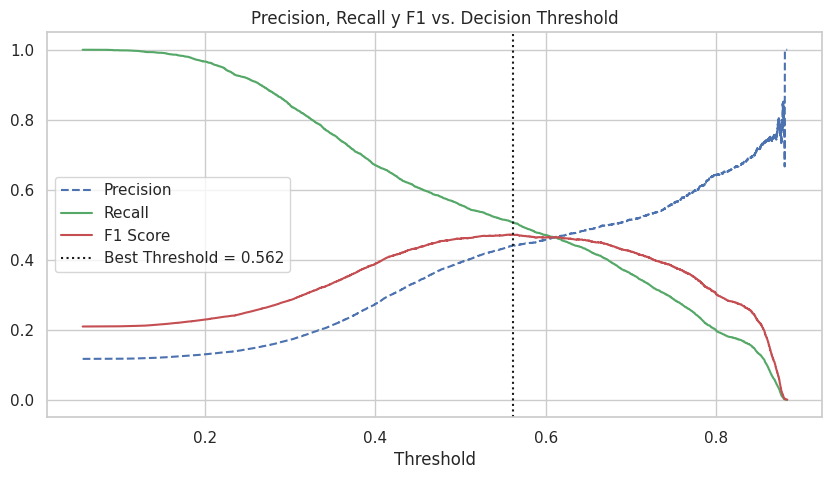

Umbral Óptimo Encontrado: 0.5621
Expected Precision at config: 0.4417
Expected Recall at config: 0.5074
Expected F1 at config: 0.4723


In [5]:
def find_best_threshold(y_true, y_prob):
    """
    Encuentra el threshold que maximiza el F1-Score y plotea 
    Precision-Recall tradeoff contra los umbrales.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calcular el F1 score para cada threshold posible (Evitamos divisiones por cero)
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score')
    
    plt.axvline(x=best_threshold, color='k', linestyle=':', label=f'Best Threshold = {best_threshold:.3f}')
    
    plt.title('Precision, Recall y F1 vs. Decision Threshold')
    plt.xlabel('Threshold')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
    
    print(f"Umbral Óptimo Encontrado: {best_threshold:.4f}")
    print(f"Expected Precision at config: {precisions[best_idx]:.4f}")
    print(f"Expected Recall at config: {recalls[best_idx]:.4f}")
    print(f"Expected F1 at config: {best_f1:.4f}")
    
    return best_threshold

# Entrenamos el modelo final con los mejores hiperparámetros de Optuna
best_lgbm = LGBMClassifier(**study.best_params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
final_pipeline = create_pipeline(estimator=best_lgbm)

# Ajuste sobre todos los datos de Train
final_pipeline.fit(X_train, y_train)

# Calculamos el Umbral ideal basado en Data de Entrenamiento (para evitar fugar información usando Test)
# Opcional: Podría calcularse con Train-CV, pero entrenar predict_proba suele comportar sesgo si no usamos cross_val_predict
y_train_proba = cross_val_predict(
    final_pipeline, X_train, y_train, cv=5, method='predict_proba'
)[:, 1]

print("Buscando modelo balanceado y estable...")
optimal_threshold = find_best_threshold(y_train, y_train_proba)

## 5. Evaluación Final (Test Set)

Compararemos ahora el rendimiento real bajo la ventana del dataset final de **Test**, aplicando nuestro nuevo umbral personalizado.

--- Evaluación con Threshold: 0.5621 ---

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7985
           1       0.45      0.52      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043



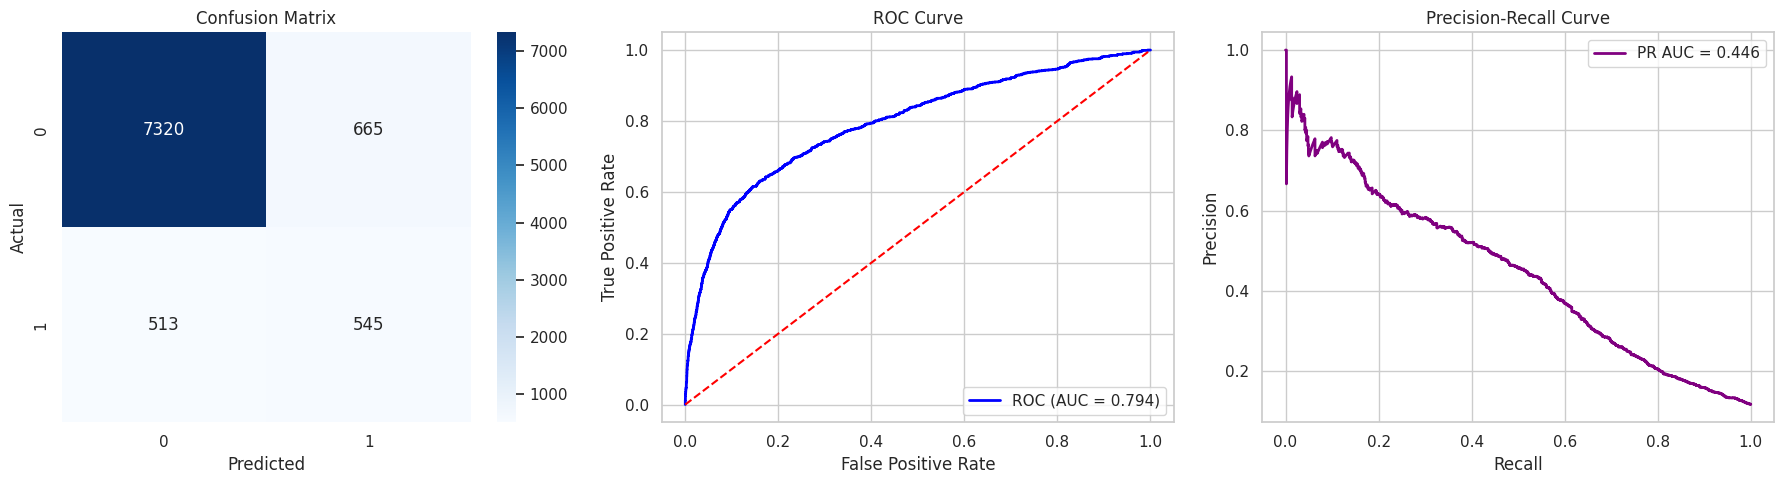

In [6]:
def evaluate_model(pipeline, X_test, y_test, threshold=0.5):
    """
    Genera métricas completas para analizar el rendimiento del dataset de Test.
    """
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f"--- Evaluación con Threshold: {threshold:.4f} ---\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Matriz Confusión
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    
    # Curva Precision-Recall
    precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recalls, precisions)
    axes[2].plot(recalls, precisions, color='purple', lw=2, label=f'PR AUC = {pr_auc:.3f}')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

# Evaluación con el Umbral Optimizado
evaluate_model(final_pipeline, X_test, y_test, threshold=optimal_threshold)

## 6. Interpretación: Feature Importance

Finalmente, analizaremos qué variables determinan que un cliente se suscriba.

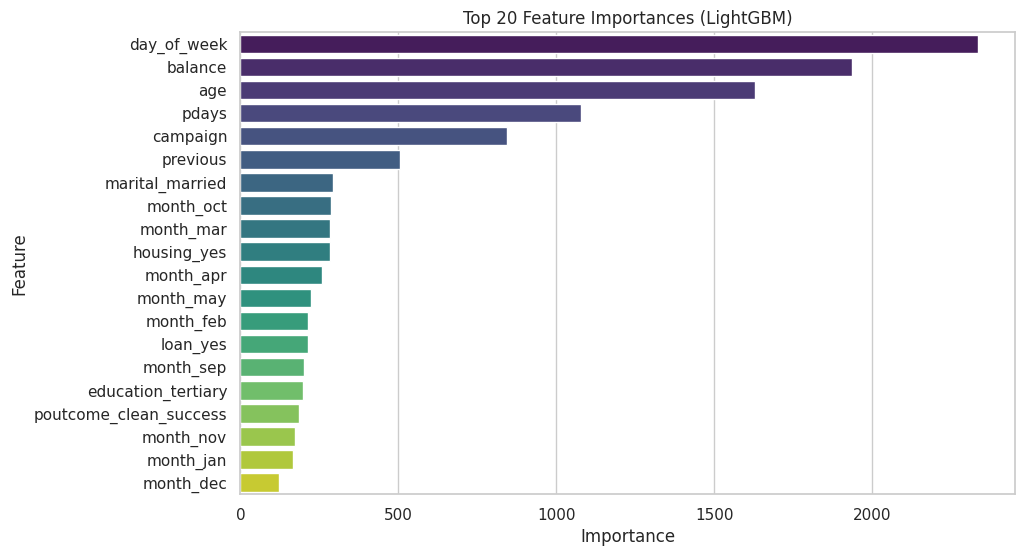

In [7]:
def plot_feature_importance(pipeline, top_n=20):
    model = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessor']
    
    # Extraemos los nombres generados mediante el transformer
    num_cols = preprocessor.transformers_[0][2]
    cat_cols_encoded = preprocessor.transformers_[1][1].named_steps['encoder'].get_feature_names_out(preprocessor.transformers_[1][2])
    
    # Variables passthrough (booleanas agregadas) del custom transformer
    passthroughs = ['contacted_before', 'has_previous_contact', 'is_senior', 
                    'is_young', 'has_negative_balance', 'has_high_balance']
    
    all_feature_names = list(num_cols) + list(cat_cols_encoded) + passthroughs
    
    # Importancias clásicas en árboles (Gain/Split) originarias de ligthgbm
    importances = model.feature_importances_
    
    # Asegurar coincidencia de tamaños (A veces passthrough arroja discrepancias dependiendo de `remainder`)
    min_len = min(len(all_feature_names), len(importances))
    
    feat_imp = pd.Series(importances[:min_len], index=all_feature_names[:min_len]).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(top_n).values, y=feat_imp.head(top_n).index, palette='viridis')
    plt.title(f'Top {top_n} Feature Importances (LightGBM)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

try:
    plot_feature_importance(final_pipeline)
except Exception as e:
    print("El feature array requirió ajustes de mapeado estricto post-passthrough: ", e)